# Module 20 - Non-PE Script Classification
## Baseline Model and Exploratory Data Analysis

**Objective:** Classify non-PE script files as malicious vs. clean using metadata and features derived from `HeaderDecoded` and `FooterDecoded`.

**Author:** UC Berkeley ML & AI Professional Certificate - Module 20 Capstone

**Date:** December 2025

---

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Imports successful")

✓ Imports successful


## 2. Data Loading

**Primary Dataset:** `NonPeFileCuration_FilesWithAnyMLScore_7days.tsv`
- Contains suspicious/malicious non-PE script files
- Label: `IsMatch` column
- Will be used for training and testing (internal split)

**Optional:** `NonPeFileCuration_AllFiles_7days.tsv`
- All non-PE files (clean + malicious mix)
- Used only for comparative EDA

In [2]:
# Load primary supervised dataset
df = pd.read_csv('Data/NonPeFileCuration_FilesWithAnyMLScore_7days.tsv', sep='\t', low_memory=False)

# Create label and ml_score columns
df['label'] = df['IsMatch'].astype(int)
df['ml_score'] = df['ML'].astype(float)

print(f"Primary dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Primary dataset shape: (1145, 13)

Columns: ['Sha256', 'Machines', 'ML', 'FileNames', 'VPaths', 'Urls', 'RateExe', 'Filename', 'HeaderDecoded', 'FooterDecoded', 'IsMatch', 'label', 'ml_score']


## 3. Initial Data Exploration

In [3]:
# First few rows
print("First few rows:")
display(df.head())

First few rows:


,Sha256,Machines,ML,FileNames,VPaths,Urls,RateExe,Filename,HeaderDecoded,FooterDecoded,IsMatch,label,ml_score
0,006b6012a3c9474c9bd363eabe0e61c294c7af006c0bfa3a4bbd25d6f4503ff5,10,0.201330,"['SWIFT Copy-67100102325.7z', 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855']","['SWIFT Copy-67100102325.7z->SWIFT Copy-67100102325.jse', 'e3b0c44298fc1c149afbf4c8996fb92427ae4...","['', 'https://fairwaymc.service-now.com/sys_attachment.do?sys_id=9b3fff712b65fa505839f247ce91bf6...",0.0,G:\WDSRoot\SAApp\StreamingStaticAnalysisService\work\5942b220066c4289a44ccef5359af61e\006b6012a3...,"function _0x3108(_0x13369f,_0x5c38ac){var _0x454cf8=_0x47d5();return _0x3108=function(_0x4f98f9,...","8bcb(0x90c),_0x4d7d64[_0x3d8bcb(0x9e2)],_0x4d7d64[_0x3d8bcb(0x2bb)],_0x4d7d64['FbPen'],_0x4d7d64...",False,0,0.201330
1,780f19d8bc2f0bfd57de9adbf72747588f87bcfb6738d1fcd4e807bde8e1b1c9,15,0.366425,"['FACTURA ELECTRONICA EMITIDA Y ELABORADA ANTE DIAN 321982732247815367998125378314.js', 'factura...",[''],['https://sgb-enam-86.75b8814ba98de5c51115eceabd5fc23e.r2.cloudflarestorage.com/4H8V9-VXVT1-9IRR...,0.0,G:\WDSRoot\SAApp\StreamingStaticAnalysisService\work\d5ab48f57e52459b855be3ec1ce4808f\780f19d8bc...,"var steely = new ActiveXObject(""Scripting.FileSystemObject""); var dianalytic = steely.GetP...","tis += ""Ö¸ð¦ð§â­ãâµ§à­¦áá®¢á¦©á¾ðâªââ""; this.paramastitis += ""Ö¸ð¦ð§â...",False,0,0.366425
2,382ac9ea60bb0ba40c9eb0815f4ec7f60e248fc136d3055c411d09709e1b9b31,6,0.013589,"['basic-text.pdf', 'Attachments_8.zip', 'prototyp-pdf.zip', 'Testing json.pdf']","['', 'Attachments_8.zip->basic-text.pdf', 'prototyp-pdf.zip->prototyp_pdf/data/another2.pdf', 'p...","['https://sample-files.com/downloads/documents/pdf/basic-text.pdf', 'http://localhost:48900/Dyna...",0.0,G:\WDSRoot\SAApp\StreamingStaticAnalysisService\work\144b97edb3664a6790a4f4c63eca8696\382ac9ea60...,%PDF-1.4 %Óëéá 1 0 obj <</Title (Sample Document for PDF Testing) /Creator (Mozilla/5.0 \(Window...,ç$èÖQæ°uõJeºÁzÙi~XdI2'ÌåÌªZl<&$QÉDc§t±£^Ù ³Zf¢¦(I;)?K:FåäZBaé$ãùÑ'R=ß58âe´c°%...,False,0,0.013589
3,346a0d8ca8ef96b846dd6c7736bfcbaa888ba81aedc1f3acabfdcdbff82a07f8,1,0.000100,['luka.js'],[''],['https://webogram.org/'],0.0,G:\WDSRoot\RTSSAApp\StreamingStaticAnalysisService\work\606a481ce085460d935f5d9b602c3fa0\346a0d8...,"var protocol,url,data;(function(){var Sex='',fRc=247-236;function jwf(i){var j=1564280;var w=i.l...","var protocol,url,data;(function(){var Sex='',fRc=247-236;function jwf(i){var j=1564280;var w=i.l...",True,1,0.000100
4,117ca1252de9ce7f7ed9dfe84f5c2f7ca5d0e7294404251599cd03f5d647575a,22,0.628463,"['DOCUMENTO FACTURA ELECTRONICA DE VENTA EMITIDA 12708132920173692074354.js', 'DOCUMENTO FACTURA...",[''],['https://sgb-enam-32.75b8814ba98de5c51115eceabd5fc23e.r2.cloudflarestorage.com/BRFFF-FUTTB-S7DC...,0.0,G:\WDSRoot\SAApp\StreamingStaticAnalysisService\work\52ba4d36a32e41638b3de6b2f0ddc844\117ca1252d...,"var roomy = new ActiveXObject(""Scripting.FileSystemObject""); var horsewhips = roomy.GetPar...","°Ïâ¹áâá¿á«âá¼""; this.godly += ""Ïà°Öªá¬á¼áá´°Ïâ¹áâá¿á«âá¼""; ...",False,0,0.628463


In [4]:
# Dataset info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1145 entries, 0 to 1144
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sha256         1145 non-null   object 
 1   Machines       1145 non-null   int64  
 2   ML             1145 non-null   float64
 3   FileNames      1145 non-null   object 
 4   VPaths         1145 non-null   object 
 5   Urls           1145 non-null   object 
 6   RateExe        1145 non-null   float64
 7   Filename       1145 non-null   object 
 8   HeaderDecoded  1142 non-null   object 
 9   FooterDecoded  1136 non-null   object 
 10  IsMatch        1145 non-null   bool   
 11  label          1145 non-null   int64  
 12  ml_score       1145 non-null   float64
dtypes: bool(1), float64(3), int64(2), object(7)
memory usage: 108.6+ KB


In [5]:
# Basic statistics
print("Basic Statistics:")
df.describe(include='all')

Basic Statistics:


,Sha256,Machines,ML,FileNames,VPaths,Urls,RateExe,Filename,HeaderDecoded,FooterDecoded,IsMatch,label,ml_score
count,1145,1145.000000,1145.000000,1145,1145,1145,1145.000000,1145,1142,1136,1145,1145.000000,1145.000000
unique,1029,NaN,NaN,925,587,712,NaN,1144,907,864,2,NaN,NaN
top,0b2834bdaa76c1e6434214330f16cc60fa842fadf29deb4fa68407afa305d9f3,NaN,NaN,['e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855'],[''],['about:internet'],NaN,G:\WDSRoot\SAApp\StreamingStaticAnalysisService\work\7a25d757d3634d6882e949eeee92db27\afd2ee205e...,MZ,"RReleaseData?audienceFFN=$FFN"" $url = if ($windowsBuild -lt 9200) { ""$baseUrl&osver=Client|6.1""...",False,NaN,NaN
freq,4,NaN,NaN,41,551,87,NaN,2,21,32,823,NaN,NaN
mean,NaN,46.152838,0.313041,NaN,NaN,NaN,0.000114,NaN,NaN,NaN,NaN,0.281223,0.313041
std,NaN,686.633710,0.402397,NaN,NaN,NaN,0.001990,NaN,NaN,NaN,NaN,0.449792,0.402397
min,NaN,1.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,1.000000,0.001972,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,0.001972
50%,NaN,1.000000,0.053200,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,0.053200
75%,NaN,9.000000,0.714700,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,0.714700


In [6]:
# Class distribution
print("Class Distribution (label):")
print(df['label'].value_counts())
print("\nClass Balance:")
print(df['label'].value_counts(normalize=True))

Class Distribution (label):
label
0    823
1    322
Name: count, dtype: int64

Class Balance:
label
0    0.718777
1    0.281223
Name: proportion, dtype: float64


In [7]:
# Missing values
print("Missing Values:")
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percent': missing_pct
}).sort_values('Missing_Count', ascending=False)

display(missing_df[missing_df['Missing_Count'] > 0])

Missing Values:


,Missing_Count,Missing_Percent
FooterDecoded,9,0.786026
HeaderDecoded,3,0.262009


## 4. Data Cleaning

Based on the missing values analysis above, we'll handle missing data appropriately.

In [23]:
# Check for duplicate rows
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df)}")
else:
    print("No duplicates found.")

Total rows: 1145
Duplicate rows: 0
No duplicates found.


## 5. Outlier Analysis

We'll examine outliers in key numeric features to identify anomalies.

In [24]:
# Analyze outliers in ML score and Machines using IQR method
numeric_features = ['ML', 'Machines']

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"\n{feature}:")
    print(f"  Q1={Q1:.4f}, Q3={Q3:.4f}, IQR={IQR:.4f}")
    print(f"  Lower bound={lower_bound:.4f}, Upper bound={upper_bound:.4f}")
    print(f"  Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
print("\n✓ Outlier analysis complete. Outliers are expected in security datasets and will be retained.")


ML:
  Q1=0.0020, Q3=0.7147, IQR=0.7127
  Lower bound=-1.0671, Upper bound=1.7838
  Number of outliers: 0 (0.00%)

Machines:
  Q1=1.0000, Q3=9.0000, IQR=8.0000
  Lower bound=-11.0000, Upper bound=21.0000
  Number of outliers: 182 (15.90%)

✓ Outlier analysis complete. Outliers are expected in security datasets and will be retained.


In [8]:
# Check ML score distribution
print("ML Score Statistics:")
print(df['ml_score'].describe())
print("\nML Score by Label:")
print(df.groupby('label')['ml_score'].describe())

ML Score Statistics:
count    1145.000000
mean        0.313041
std         0.402397
min         0.000000
25%         0.001972
50%         0.053200
75%         0.714700
max         1.000000
Name: ml_score, dtype: float64

ML Score by Label:
       count      mean       std  min       25%       50%       75%  max
label                                                                   
0      823.0  0.381213  0.416990  0.0  0.007387  0.145950  0.911950  1.0
1      322.0  0.138799  0.299061  0.0  0.000400  0.006706  0.055186  1.0


## 6. Feature Engineering

Creating features from:
1. **HeaderDecoded** and **FooterDecoded** text (length, lines, suspicious tokens)
2. **ML score** (continuous and binary threshold features)
3. **Metadata** (number of machines)

In [9]:
# Define suspicious tokens to look for in scripts
suspicious_tokens = [
    'fromCharCode', 'atob', 'eval', 'WScript', 'powershell', 
    'Invoke-Expression', 'iex', 'DownloadString', 'DownloadFile',
    'Shell', 'exec', 'CreateObject', 'ActiveXObject'
]

def count_suspicious_tokens(text, tokens):
    """Count occurrences of suspicious tokens in text (case-insensitive)"""
    if pd.isna(text) or not isinstance(text, str):
        return 0
    text_lower = text.lower()
    return sum(text_lower.count(token.lower()) for token in tokens)

print("Engineering features from HeaderDecoded and FooterDecoded...")

# Header features
df['header_length_chars'] = df['HeaderDecoded'].fillna('').astype(str).apply(len)
df['header_num_lines'] = df['HeaderDecoded'].fillna('').astype(str).apply(lambda x: x.count('\n') + 1 if x else 0)
df['header_suspicious_tokens'] = df['HeaderDecoded'].apply(lambda x: count_suspicious_tokens(x, suspicious_tokens))

# Footer features
df['footer_length_chars'] = df['FooterDecoded'].fillna('').astype(str).apply(len)
df['footer_num_lines'] = df['FooterDecoded'].fillna('').astype(str).apply(lambda x: x.count('\n') + 1 if x else 0)
df['footer_suspicious_tokens'] = df['FooterDecoded'].apply(lambda x: count_suspicious_tokens(x, suspicious_tokens))

# ML score features
df['high_ml_score'] = (df['ml_score'] > 0.02).astype(int)

# Additional metadata features
if 'Machines' in df.columns:
    df['num_machines'] = df['Machines']

print("✓ Feature engineering complete")
print(f"\nNew features created: {len([c for c in df.columns if any(x in c for x in ['header_', 'footer_', 'high_ml'])])}")

Engineering features from HeaderDecoded and FooterDecoded...
✓ Feature engineering complete

New features created: 7


In [10]:
# Summary of engineered features
feature_cols = [
    'header_length_chars', 'footer_length_chars',
    'header_num_lines', 'footer_num_lines',
    'header_suspicious_tokens', 'footer_suspicious_tokens',
    'ml_score', 'high_ml_score'
]

# Add num_machines if it exists
if 'num_machines' in df.columns:
    feature_cols.append('num_machines')

print("Engineered features summary:")
print(df[feature_cols].describe())

Engineered features summary:
       header_length_chars  footer_length_chars  header_num_lines  \
count          1145.000000          1145.000000       1145.000000   
mean           2933.159825          2951.704803          0.997380   
std            1654.752121          1637.543295          0.051142   
min               0.000000             0.000000          0.000000   
25%             818.000000          1015.000000          1.000000   
50%            4096.000000          4096.000000          1.000000   
75%            4096.000000          4096.000000          1.000000   
max            4096.000000          4096.000000          1.000000   

       footer_num_lines  header_suspicious_tokens  footer_suspicious_tokens  \
count       1145.000000               1145.000000               1145.000000   
mean           0.992140                  2.939738                  3.337118   
std            0.088348                  6.204473                  8.534477   
min            0.000000          

## 7. Exploratory Data Analysis (EDA)

### 7.1 Class Distribution

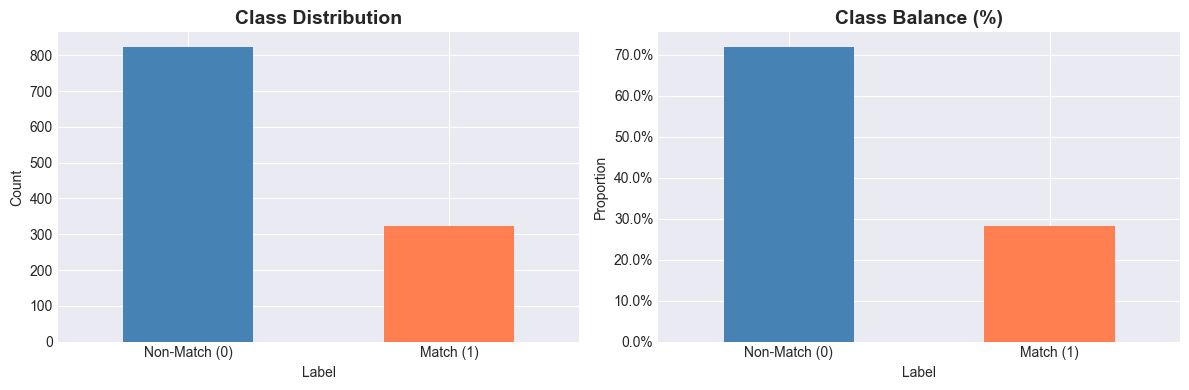


Observation: Check the balance between Match and Non-Match classes.
✓ Saved: images/class_distribution.png


In [31]:
# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Non-Match (0)', 'Match (1)'], rotation=0)

# Percentage plot
df['label'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('Class Balance (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(['Non-Match (0)', 'Match (1)'], rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))

plt.tight_layout()
plt.savefig('images/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nObservation: Check the balance between Match and Non-Match classes.")
print("✓ Saved: images/class_distribution.png")


### 7.2 Feature Distributions by Label

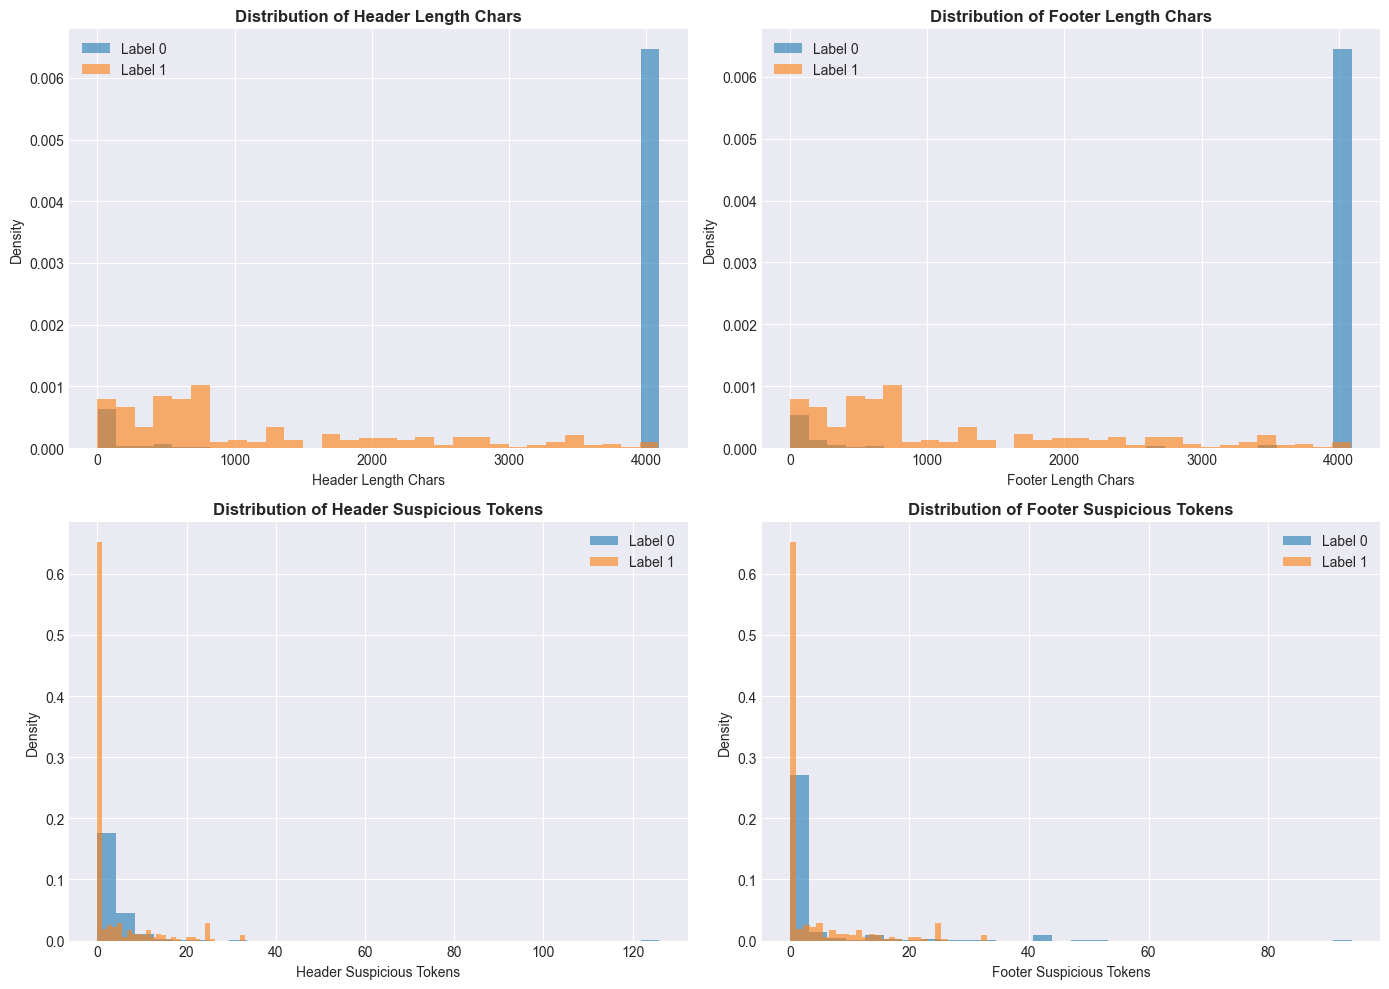


Observation: Compare how feature distributions differ between the two classes.
✓ Saved: images/feature_distributions.png


In [32]:
# Select key features for visualization
viz_features = ['header_length_chars', 'footer_length_chars', 
                'header_suspicious_tokens', 'footer_suspicious_tokens']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(viz_features):
    for label in [0, 1]:
        data = df[df['label'] == label][feature].dropna()
        axes[idx].hist(data, bins=30, alpha=0.6, 
                      label=f'Label {label}',
                      density=True)
    
    axes[idx].set_xlabel(feature.replace('_', ' ').title())
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'Distribution of {feature.replace("_", " ").title()}', 
                       fontweight='bold')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('images/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nObservation: Compare how feature distributions differ between the two classes.")
print("✓ Saved: images/feature_distributions.png")


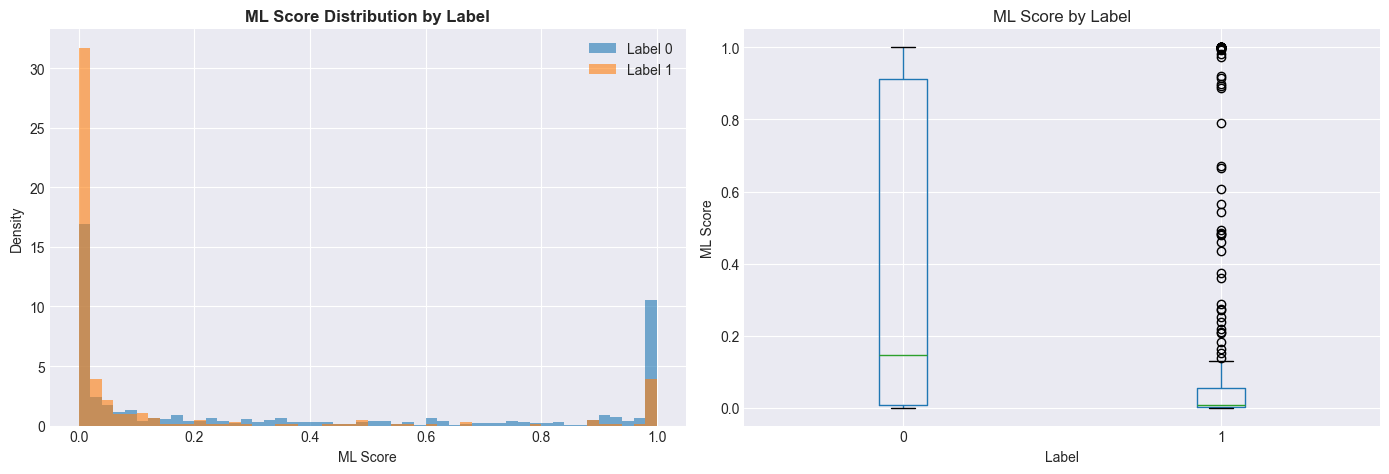


Observation: ML score is a key discriminative feature.


In [13]:
# ML score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label in [0, 1]:
    data = df[df['label'] == label]['ml_score'].dropna()
    axes[0].hist(data, bins=50, alpha=0.6, label=f'Label {label}', density=True)

axes[0].set_xlabel('ML Score')
axes[0].set_ylabel('Density')
axes[0].set_title('ML Score Distribution by Label', fontweight='bold')
axes[0].legend()

# Boxplot
df.boxplot(column='ml_score', by='label', ax=axes[1])
axes[1].set_xlabel('Label')
axes[1].set_ylabel('ML Score')
axes[1].set_title('ML Score by Label')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

print("\nObservation: ML score is a key discriminative feature.")

### 7.4 Correlation Matrix

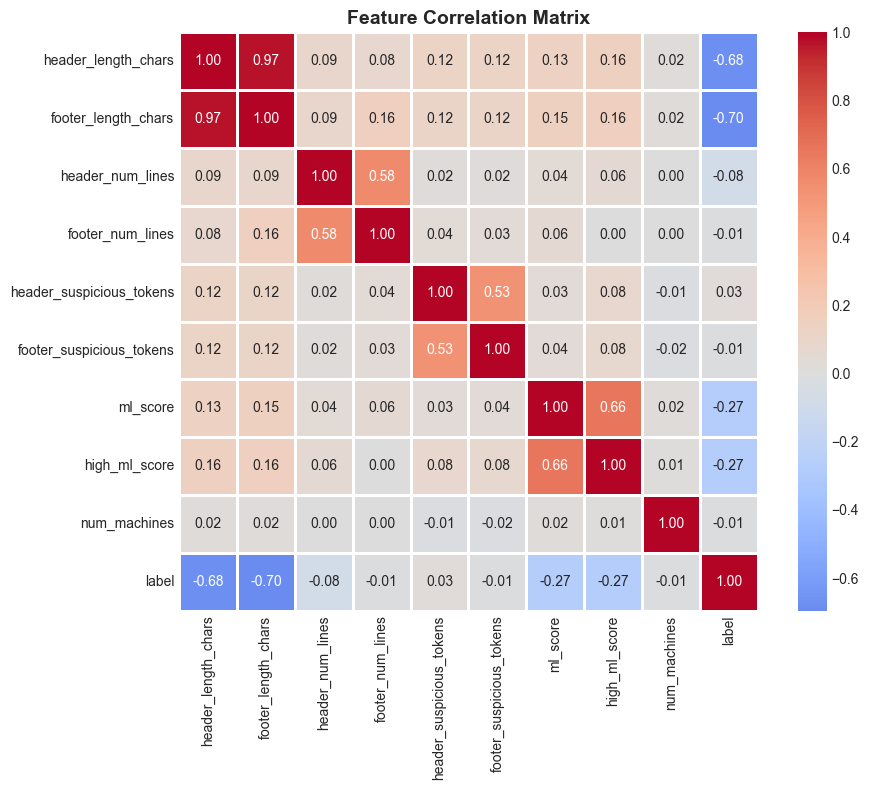


Observation: Check which features are most correlated with the label.
✓ Saved: images/correlation_matrix.png


In [33]:
# Correlation matrix for numeric features
corr_features = feature_cols + ['label']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nObservation: Check which features are most correlated with the label.")
print("✓ Saved: images/correlation_matrix.png")


## 8. Baseline Model: Logistic Regression

### 8.1 Data Preparation

### 8.2 Train-Test Split

In [16]:
# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 916
Test set size: 229

Training set class distribution:
label
0    658
1    258
Name: count, dtype: int64

Test set class distribution:
label
0    165
1     64
Name: count, dtype: int64


### 8.3 Model Training

**Model Selection Rationale:**
- **Logistic Regression** is chosen as the baseline model for its interpretability and efficiency
- **class_weight='balanced'** handles the class imbalance (28% Match vs 72% Non-Match)
- Provides coefficient values to understand feature importance

In [17]:
# Train Logistic Regression with balanced class weights
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

print("✓ Model trained successfully")
print("\nFeature coefficients:")
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df)

✓ Model trained successfully

Feature coefficients:
                    Feature  Coefficient
6                  ml_score    -1.434142
3          footer_num_lines     1.340269
7             high_ml_score    -0.799142
2          header_num_lines    -0.390676
4  header_suspicious_tokens     0.091900
5  footer_suspicious_tokens     0.005683
1       footer_length_chars    -0.001259
0       header_length_chars    -0.000034
8              num_machines     0.000012


C:\Users\rezatajvidi\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 8.4 Model Evaluation

**Evaluation Metrics:**
- **ROC-AUC**: Measures discrimination ability across all thresholds
- **PR-AUC**: Better for imbalanced datasets, focuses on positive class
- **Precision, Recall, F1-Score**: Standard classification metrics
- **Confusion Matrix**: Shows true/false positives and negatives

**Rationale for Metrics:**
In security applications, both false positives (flagging clean files) and false negatives (missing malicious files) have costs. ROC-AUC and PR-AUC provide threshold-independent performance measures, while precision/recall allow threshold tuning based on operational requirements.

In [18]:
# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Classification report
print("Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Non-Match', 'Match']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n{'='*60}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc:.4f}")
print(f"{'='*60}")

Classification Report:
              precision    recall  f1-score   support

   Non-Match       0.93      0.87      0.90       165
       Match       0.71      0.84      0.77        64

    accuracy                           0.86       229
   macro avg       0.82      0.86      0.84       229
weighted avg       0.87      0.86      0.86       229


ROC-AUC Score: 0.9127
PR-AUC Score: 0.7989


### 8.5 Confusion Matrix

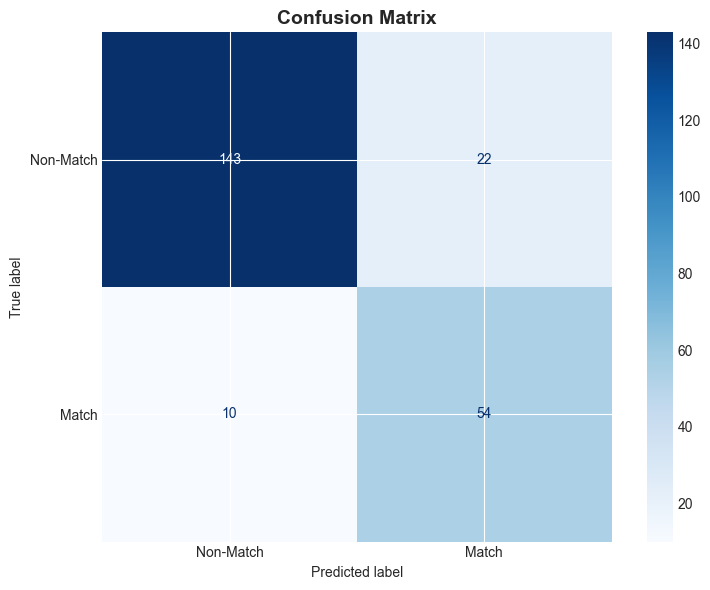


Confusion Matrix Interpretation:
True Negatives: 143
False Positives: 22
False Negatives: 10
True Positives: 54
✓ Saved: images/confusion_matrix.png


In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Match', 'Match'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")
print("✓ Saved: images/confusion_matrix.png")


### 8.6 Precision-Recall Curve

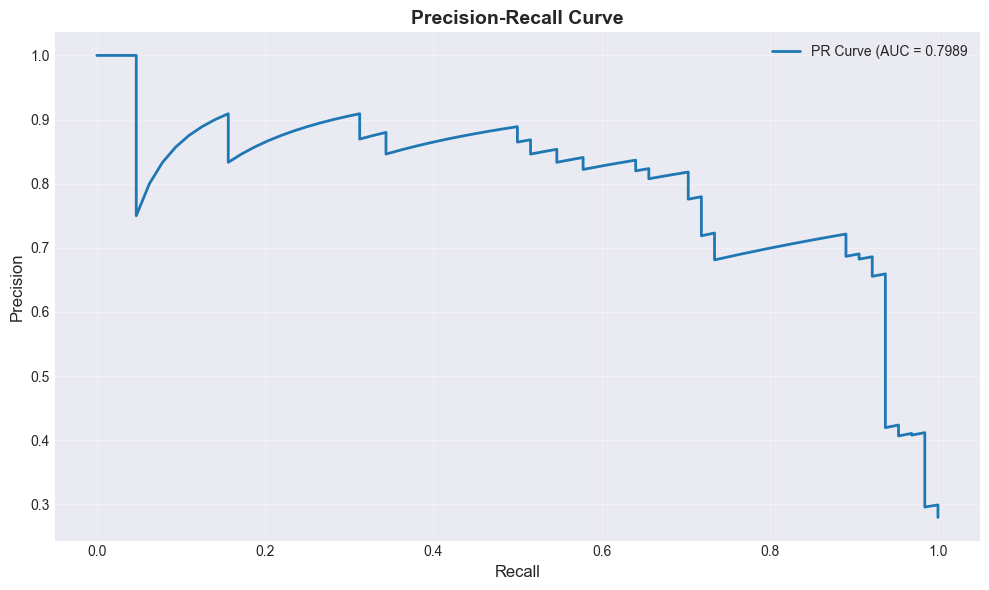


Precision-Recall curve shows the trade-off at different thresholds.
✓ Saved: images/precision_recall_curve.png


In [35]:
# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, linewidth=2, label=f'PR Curve (AUC = {pr_auc:.4f}')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPrecision-Recall curve shows the trade-off at different thresholds.")
print("✓ Saved: images/precision_recall_curve.png")


### 8.7 Performance at Different Thresholds

In [21]:
# Evaluate at different probability thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_to_test = [0.5, 0.7, 0.8, 0.9]

print("Performance at Different Probability Thresholds:")
print("=" * 80)

for thresh in thresholds_to_test:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    print(f"\nThreshold = {thresh:.1f}")
    print(f"  Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
    print(f"  Predictions: {y_pred_thresh.sum()} positive out of {len(y_pred_thresh)} samples")

print("\n" + "=" * 80)

Performance at Different Probability Thresholds:

Threshold = 0.5
  Precision: 0.7105 | Recall: 0.8438 | F1-Score: 0.7714
  Predictions: 76 positive out of 229 samples

Threshold = 0.7
  Precision: 0.6857 | Recall: 0.7500 | F1-Score: 0.7164
  Predictions: 70 positive out of 229 samples

Threshold = 0.8
  Precision: 0.7188 | Recall: 0.7188 | F1-Score: 0.7188
  Predictions: 64 positive out of 229 samples

Threshold = 0.9
  Precision: 0.8500 | Recall: 0.5312 | F1-Score: 0.6538
  Predictions: 40 positive out of 229 samples



## 9. Summary and Key Findings